# Feature Selection & Cancer Prediction
The data used for this tutorial is an RNA-seq gene expression data for different cancer types. The rows represent cancer samples and the columns represent gene count values. The last column contains the cancer categories.

The original data can found here: https://archive.ics.uci.edu/ml/datasets/gene+expression+cancer+RNA-Seq#

## Required Libraries
 - numpy
 - matplotlib
 - seaborn
 - pandas
 - scikit

## Import Python libraries

In [ ]:
#data handling
import pandas as pd
import numpy as np

#data visualization
import matplotlib.pyplot as plt
import seaborn as sns

#preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import label_binarize
from sklearn.preprocessing import MinMaxScaler

#feature selection
from sklearn.feature_selection import mutual_info_classif

#classification
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier

# performance metrics
from sklearn.metrics import balanced_accuracy_score,f1_score,precision_score, recall_score
from sklearn.metrics import classification_report
#from sklearn.metrics import confusion_matrix
#from sklearn.metrics import plot_confusion_matrix
#from sklearn.metrics import roc_curve,auc
#from sklearn.metrics import roc_auc_score

## Read data

In [ ]:

#read data directly from a github repository


file_url='https://github.com/vappiah/Machine-Learning-Tutorials/raw/main/datasets/cancer_gene_expression.zip'

dataframe=pd.read_csv(file_url)





## Data Exploration & Cleaning




In [ ]:
#let's check the number of samples and features
#note:the last column contain the labels. it is not considered as a feature

print(dataframe.shape)

In [ ]:
#let's check some of the columns (first, second and third columns)
print(dataframe.columns[0:3])

In [ ]:
#lets check the name of the last column of this dataframe

dataframe.columns[-1]

In [ ]:
#check for missing values
datanul=dataframe.isnull().sum()
g=[i for i in datanul if i>0]

print('columns with missing values:%d'%len(g))

**GOOD JOB!!!!.**

In [ ]:
#let's check how many different cancer types are there in the data
#note: in this tutorial the cancer types will be referred to as classes or labels

print(dataframe['Cancer_Type'].value_counts())

We can see that there are 5 classes/cancer types. And you can also see the number of samples diagnosed with a cancer type
      

In [ ]:
#plot a bar chat to display the class distribution

dataframe['Cancer_Type'].value_counts().plot.bar()


## **Data preprocesing**
This is done to put the data in an appropriate format before modelling


In [ ]:
#we will now seperate the feature values from the class. we do this because scikit-learn requires that features and class are separated before parsing them to the classifiers.

X=dataframe.iloc[:,0:-1]
y=dataframe.iloc[:,-1]

In [ ]:
X.shape

In [ ]:
y.shape

\
**Encode labels**

The labels for this data are categorical and we therefore have to convert them to numeric forms. This is referred to as encoding. Machine learning models usually require input data to be in numeric forms, hence we encoding the labels.

In [ ]:
#let's encode target labels (y) with values between 0 and n_classes-1.
#encoding will be done using the LabelEncoder
label_encoder=LabelEncoder()
label_encoder.fit(y)
y_encoded=label_encoder.transform(y)
labels=label_encoder.classes_
classes=np.unique(y_encoded)

In [ ]:
labels

In [ ]:
classes

\
**Data Splitting**\
We will now split the data into training and test subsets.
The training data is initially parsed to the machine learning model. this is to enable the model to identify discriminatory patterns which can be used to make future predictions.
The testing data is used to evaluate the model after the training phase.

In [ ]:
#split data into training and test sets
X_train,X_test,y_train,y_test=train_test_split(X,y_encoded,test_size=0.2,random_state=42)

In [ ]:
dataframe.iloc[:,0:10].describe()

\
**Data Normalization**\
Data normalization is done so that the values are in the same range. This will improve model performance and avoid bias

In [ ]:
# scale data between 0 and 1

min_max_scaler=MinMaxScaler()
X_train_norm=min_max_scaler.fit_transform(X_train)
X_test_norm=min_max_scaler.fit_transform(X_test)

## **Feature Selection**
The purpose of feature selection is to select the subset of feature that gives the best performance.
Feature selection is a critical step when dealing with high dimensional data

In this tutorial, mutual information algorithm which is a filter method is used to compute the relevance of each feature. The top n (eg. 300) features are selected for the machine learning analysis. A comparison between the result of different feature subsets are also performed.

### Feature Selection using Mutual Information

In [ ]:
from sklearn.feature_selection import mutual_info_classif
MI=mutual_info_classif(X_train_norm, y_train)

In [ ]:
#select top n features. lets say 300.
#you can modify the value and see how the performance of the model changes

def feature_selection(MI,X_train,y_train,X_test,n_features=300):
  selected_scores_indices=np.argsort(MI)[::-1][0:n_features]
  X_train_selected=X_train[:,selected_scores_indices]
  X_test_selected=X_test[:,selected_scores_indices]

  return (X_train_selected,X_test_selected)

In [ ]:
#Build the Classifier Model
#Random Forest Classifier
def classify(X_train,y_train,X_test,y_test):
  RF=RandomForestClassifier(max_features=0.2)
  RF.fit(X_train,y_train)
  y_pred =RF.predict(X_test)
  f1score=np.round(f1_score(y_test,y_pred,average = 'weighted'),4)
  print('f1score:%0.4f'%f1score)
  return(f1score)

In [21]:
#Lets use the entire data to build the model
score_allfeatures=classify(X_train_norm,y_train,X_test_norm,y_test)

f1score:0.9689


In [22]:
type(score_allfeatures)

numpy.float64

In [ ]:
#Let try with subset of features . Lets take the top 300 features

In [23]:
X_train_filtered,X_test_filtered=feature_selection(MI,X_train_norm,y_train,X_test_norm,n_features=300)
classify(X_train_filtered,y_train,X_test_filtered,y_test)

f1score:0.9628


np.float64(0.9628)

In [24]:
#Lets try with different top features
for topfeatures in [10,20,30,40]:
    print('testing with ',topfeatures, ' top features')
    X_train_filtered,X_test_filtered=feature_selection(MI,X_train_norm,y_train,X_test_norm,n_features=topfeatures)
    classify(X_train_filtered,y_train,X_test_filtered,y_test)

testing with  10  top features
f1score:0.7406
testing with  20  top features
f1score:0.7818
testing with  30  top features
f1score:0.7518
testing with  40  top features
f1score:0.8174


In [ ]:
# Bar chart to compare the performance of the top n features

testing with  10  top features
f1score:0.7463
testing with  20  top features
f1score:0.7690
testing with  30  top features
f1score:0.7787
testing with  40  top features
f1score:0.7955


Text(0.5, 1.0, 'Scores(Feature Subsets)')

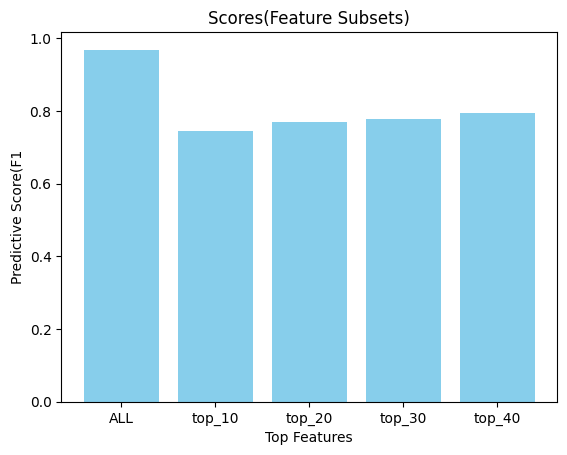

In [25]:

labels=['ALL']
scores=[score_allfeatures]
for topfeatures in [10,20,30,40]:
    print('testing with ',topfeatures, ' top features')
    X_train_filtered,X_test_filtered=feature_selection(MI,X_train_norm,y_train,X_test_norm,n_features=topfeatures)
    score=classify(X_train_filtered,y_train,X_test_filtered,y_test)
    labels.append('top_%d'%topfeatures)
    scores.append(score)

plt.bar(labels, scores, color='skyblue')

# Add labels and title
plt.xlabel('Top Features')
plt.ylabel('Predictive Score(F1')
plt.title('Scores(Feature Subsets)')

### Observation
A better or similar predictive performance was obtained using smaller feature subset. This highlights the importance of using feature selection.



# Exercise

Perform feature selection using mutual information  on the malaria dataset. (Provided earlier).
Identify the topfeatures that give the best predictive performance. (eg. top1 , top2, top3, top4,....)

